# Fiery results - epochs

## NB y- and x-axis should be inverted

In [57]:
# imports

import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import log_loss
import pickle
import torch.nn.functional as F


In [2]:
#from helper import get_results, find_gaussians, find_gaussians_cal, get_models_in_rings, find_instance_centers, plot_seg, \
#                   generate_rel_diagrams, get_clusters

In [3]:
from helper import generate_rel_diagrams

In [4]:
from binnings import *
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression

In [5]:
indices_val, indices_test = train_test_split(np.arange(0, 5119), test_size=0.8, random_state=1001)

In [6]:
def get_val_test(probs, ys, indices, indices_test = indices_test, indices_val = indices_val):
## Get test indices

    all_indices_test = []
    all_indices_val = []

    for i in indices_test:
        all_indices_test += list(np.where(i == indices)[0])

    for i in indices_val:
        all_indices_val += list(np.where(i == indices)[0])

    all_indices_test = np.array(all_indices_test)
    all_indices_test.sort()

    all_indices_val = np.array(all_indices_val)
    all_indices_val.sort()
    
    return (probs[all_indices_val], ys[all_indices_val]), (probs[all_indices_test], ys[all_indices_test])

In [7]:
from betacal import BetaCalibration

def cal_obj(probs_val, probs_test, ys_val, ys_test):
    
    model = BetaCalibration()  # Is beta or Iso used for final?
    model.fit(probs_val, ys_val)
    
    ewb = EqualWidthBinning(np.clip(probs_test, 0, 1), ys_test, None, n_bins = 10)
    print("ECE test uncal:", ewb.ECE_abs)
    
    probs_test_objcal = model.predict(probs_test)
    
    ewb = EqualWidthBinning(probs_test_objcal, ys_test, None, n_bins = 10)
    print("ECE test cal:", ewb.ECE_abs)
    
    return probs_test_objcal

In [8]:
def rel_diag_quantiles(data, l = 100, nr_future = 0, extra_str = "width", label = ""):
    qs = np.linspace(1/l, 1, l)
    plt.plot(qs, np.quantile(data, qs), label = label)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("Predicted Cumulative Distribution")
    plt.ylabel("Empirical Cumulative Distribution")
    plt.title("Regression Calibration (%s, f=%i)" % (extra_str, nr_future))

In [9]:
def generate_rel_diagrams(preds, ys, equal_size = False, n_bins=10, nr_future = 0, 
                          add_red_marker = True, title_str = "Reliability diagram (f=%i)"):
    
    if equal_size:
        binning_method = EqualSizeBinning
    else:
        binning_method = EqualWidthBinning        
        
    
       
    preds_test_cal = preds
    ys_test = ys

    if equal_size:
        fig, ax = plt.subplots(figsize=(3.7,3.7))
    else:
        fig, (ax, ax2) = plt.subplots(2, 1, figsize=(3.7,4.7), gridspec_kw={'height_ratios': [3, 1]})
        
        #ax2.xaxis.tick_top()
        
        ax2.tick_params(
        axis='x',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=True,         # ticks along the top edge are off
        labelbottom=False,
        labeltop=False) # labels along the bottom edge are off
    
    
        ax = plt.subplot(211)
    
    binning = binning_method(preds_test_cal, ys_test, None, n_bins=n_bins)
    print("\nECE_abs:", binning.ECE_abs)
    
    if not equal_size:
        polygons = binning.construct_plt_polygons_slope_1()
    else:
        polygons = binning.construct_plt_polygons_flat()

    if not equal_size:
        plt.xlim(0,1)
        plt.ylim(0,1)
    else:
        plt.yscale('log')
        plt.xscale('log')
        plt.xlabel("Predicted probability", fontsize=12)

    plt.ylabel("Calibrated probability", fontsize=12)
    plt.title(title_str % nr_future)

    for polygon in polygons:
        polygon.set_alpha(1)
        ax.add_line(polygon)

    plt.plot([0,1], [0,1], "--", c="black", label="Main diagonal", zorder=2)
    
    
    conf = [np.mean(binning.binned_p[i]) for i in range(n_bins)]
    acc = [np.mean(binning.binned_y[i]) for i in range(n_bins)]
    elem_bins = [len(binning.binned_ids[i]) for i in range(n_bins)]
    
    if add_red_marker:
        plt.scatter(conf, acc, s=15, c = "red", zorder = 10)
    
    print("Bins:", elem_bins)
    print("Conf:", conf)
    print("Acc:", acc)
    
    if not equal_size:
        plt.subplot(212)
        #plt.figure(figsize=(3.7, 1))
        plt.bar(np.linspace(0, 1-1/n_bins, n_bins), elem_bins, width=1/n_bins, align="edge", edgecolor="black", lw=0.4, alpha=1)
        plt.yscale("log")
        plt.xlim(0, 1)
        plt.gca().tick_params(axis='y', which='major', labelsize=9)
        plt.gca().tick_params(axis='y', which='minor', labelsize=9)
        plt.gca().invert_yaxis()
        
        plt.xlabel("Predicted probability", fontsize=12)


## 0. Helper functions and static variables

In [10]:
PATH_labels_pedestrians = "labels_val_epoch0_pedestrians"  # Folder name
PATH_res_pedestrians = "results_val_epoch1_pedestrians_e12" # Folder name

PATH_labels_vehicles = "labels_val"
PATH_res_vehicles = "results_val"

PATH_image = "images_val" # Folder name

FILE_label = "labels_val_%i.p"   # Single file name
FILE_res = "results_val_img%i.p"  # Single file name
FILE_image = "image_val_b%i_i%i_s%i_c%i.jpg"  # Single file name

## 1. Load in necessary data

In [11]:
# Presence uncertainty

res_pres = np.load("results_all_presence_uncertainty_n=0_09_27_22_pw.npz")

probs_pres = res_pres["p"]
probs_pres_cal = res_pres["p_cal"]
ys_pres = res_pres["y"]
dist_means_pres = res_pres["dist_mean"]
indices_pres = res_pres["indices"]

(probs_val, ys_val), (probs_test, ys_test) = get_val_test(probs_pres, ys_pres, indices_pres)
(probs_cal_val, _), (probs_cal_test, _) = get_val_test(probs_pres_cal, ys_pres, indices_pres)

# Presence uncertainty calibrated

res_pres_cal = np.load("results_all_presence_uncertainty_cal_n=0_09_27_22_pw.npz")

#probs2 = res_pres_cal["p"]
probs_pres_cal2 = res_pres_cal["p_cal"]
ys_pres2 = res_pres_cal["y"]
dist_means_pres2 = res_pres_cal["dist_mean"]
indices_pres2 = res_pres_cal["indices"]

(probs2_cal_val, ys2_val), (probs2_cal_test, ys2_test) = get_val_test(probs_pres_cal2, ys_pres2, indices_pres2)


In [12]:
probs_val.shape, probs_test.shape

((3477,), (13810,))

In [13]:
probs2_cal_val.shape, probs2_cal_test.shape

((2810,), (10824,))

In [14]:
## Trajectory uncertainty
res_pres_traj = np.load("results_all_presence_uncertainty_n=4_09_27_22_pw.npz")

probs_traj = res_pres_traj["p"]
probs_cal_traj = res_pres_traj["p_cal"]
ys_traj = res_pres_traj["y"]
dist_means_traj = res_pres_traj["dist_mean"]
indices_traj = res_pres_traj["indices"]

(probs_val_f4, ys_val_f4), (probs_test_f4, ys_test_f4) = get_val_test(probs_traj, ys_traj, indices_traj)
(probs_cal_val_f4, _), (probs_cal_test_f4, _) = get_val_test(probs_cal_traj, ys_traj, indices_traj)

res_pres_cal_traj = np.load("results_all_presence_uncertainty_cal_n=4_09_27_22_pw.npz")

#probs2 = res_pres_cal["p"]
probs_cal_traj2 = res_pres_cal_traj["p_cal"]
ys_traj2 = res_pres_cal_traj["y"]
dist_means_traj2 = res_pres_cal_traj["dist_mean"]
indices_traj2 = res_pres_cal_traj["indices"]

(probs2_cal_val_f4, ys2_val_f4), (probs2_cal_test_f4, ys2_test_f4) = get_val_test(probs_cal_traj2, ys_traj2, indices_traj2)


In [15]:
probs_val_f4.shape, probs_test_f4.shape

((3441,), (13064,))

In [16]:
probs2_cal_val_f4.shape, probs2_cal_test_f4.shape

((2758,), (11005,))

In [17]:
# Location uncertainty
data_np = np.load("results_all_location_uncertainty_n=0_09_27_22_pw.npz")
quantiles = data_np["q"]
indices_loc = data_np["indices"]

(quantiles_val, _), (quantiles_test, _) = get_val_test(quantiles, quantiles, indices_loc)


# Loaction uncertainty calibrated
data_np = np.load("results_all_location_uncertainty_cal_n=0_09_27_22_pw.npz")
quantiles_cal = data_np["q"]
indices_loc_cal = data_np["indices"]

(quantiles_cal_val, _), (quantiles_cal_test, _) = get_val_test(quantiles_cal, quantiles_cal, indices_loc_cal)


In [18]:
quantiles_val.shape, quantiles_test.shape

((2497, 2), (9760, 2))

In [19]:
quantiles_cal_val.shape, quantiles_cal_test.shape

((2157, 2), (8305, 2))

In [20]:
data_np = np.load("results_all_location_uncertainty_n=4_09_27_22_pw.npz")
quantiles_traj = data_np["q"]
indices_loc_traj = data_np["indices"]

(quantiles_val_f4, _), (quantiles_test_f4, _) = get_val_test(quantiles_traj, quantiles_traj, indices_loc_traj)


data_np = np.load("results_all_location_uncertainty_cal_n=4_09_27_22_pw.npz")
quantiles_cal_traj = data_np["q"]
indices_loc_cal_traj = data_np["indices"]

(quantiles_cal_val_f4, _), (quantiles_cal_test_f4, _) = get_val_test(quantiles_cal_traj, quantiles_cal_traj, indices_loc_cal_traj)


In [21]:
quantiles_val_f4.shape, quantiles_test_f4.shape

((2508, 2), (9722, 2))

In [22]:
quantiles_cal_val_f4.shape, quantiles_cal_test_f4.shape

((2171, 2), (8691, 2))

In [23]:
# Undetected probs area 20mx10m

data_un = np.load("results_undetected_uncertainty_10m_09_27_22_pw.npz")
prob_front_un = data_un["p"]
prob_cal_front_un = data_un["p_cal"]
ys_front_un = data_un["y"]
indices_un = data_un["indices"]

(probs_val_un, ys_val_un), (probs_test_un, ys_test_un) = get_val_test(prob_front_un, ys_front_un, indices_un)
(probs_cal_val_un, _), (probs_cal_test_un, _) = get_val_test(prob_cal_front_un, ys_front_un, indices_un)


data_un = np.load("results_undetected_uncertainty_10m_cal_09_27_22_pw.npz")
prob_cal_front_un2 = data_un["p_cal"]
ys_front_un2 = data_un["y"]
indices_un2 = data_un["indices"]

(probs2_cal_val_un, ys2_val_un), (probs2_cal_test_un, ys2_test_un) = get_val_test(prob_cal_front_un2, ys_front_un2, indices_un2)


In [24]:
probs_val_un.shape, probs_test_un.shape

((1023,), (4096,))

In [25]:
probs2_cal_val_un.shape, probs2_cal_test_un.shape

((1023,), (4096,))

### 2.1 Presence uncertainty


ECE_abs: 0.1838914146721039
Bins: [361, 344, 318, 290, 256, 267, 261, 226, 239, 11248]
Conf: [0.052952472, 0.14810267, 0.24609073, 0.34698603, 0.4479219, 0.5513695, 0.6480344, 0.7482659, 0.85066503, 0.9988788]
Acc: [0.06925207756232687, 0.13372093023255813, 0.1949685534591195, 0.2793103448275862, 0.36328125, 0.3445692883895131, 0.3333333333333333, 0.37168141592920356, 0.42677824267782427, 0.8079658605974396]


/home/pohl01/markus93/miniconda3/envs/fiery/lib/python3.7/site-packages/ipykernel_launcher.py:53: MatplotlibDeprecationWarning: Passing argument *line* of unexpected type Polygon to add_line which only accepts <class 'matplotlib.lines.Line2D'> is deprecated since 3.5 and will become an error two minor releases later.


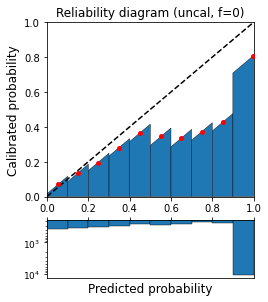

In [26]:
generate_rel_diagrams(np.clip(probs_test, 0, 1), ys_test, equal_size = False, title_str = "Reliability diagram (uncal, f=%i)")
plt.savefig("rel_diag_uncal_f0.pdf", bbox_inches='tight')


ECE_abs: 0.15882567631961897
Bins: [323, 359, 356, 376, 377, 375, 398, 456, 526, 10264]
Conf: [0.05244482388639971, 0.14696518485774035, 0.24803511342967968, 0.3508006302582738, 0.44850203779641795, 0.5503635981777265, 0.6503998626687224, 0.7533767327719695, 0.8513218052018154, 0.9968058660860167]
Acc: [0.06191950464396285, 0.14763231197771587, 0.21910112359550563, 0.3484042553191489, 0.35809018567639256, 0.448, 0.4623115577889447, 0.49780701754385964, 0.6026615969581749, 0.8229734996102884]


/home/pohl01/markus93/miniconda3/envs/fiery/lib/python3.7/site-packages/ipykernel_launcher.py:53: MatplotlibDeprecationWarning: Passing argument *line* of unexpected type Polygon to add_line which only accepts <class 'matplotlib.lines.Line2D'> is deprecated since 3.5 and will become an error two minor releases later.


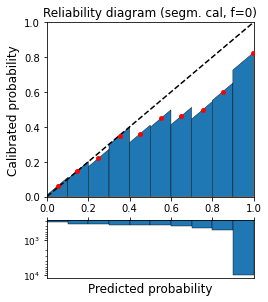

In [27]:
generate_rel_diagrams(np.clip(probs_cal_test, 0, 1), ys_test, equal_size = False, title_str = "Reliability diagram (segm. cal, f=%i)")
plt.savefig("rel_diag_segm_cal_f0.pdf", bbox_inches='tight')


ECE_abs: 0.11012941275537037
Bins: [362, 277, 260, 224, 206, 214, 200, 240, 317, 8524]
Conf: [0.050215219867962874, 0.1496009581968756, 0.2451272852571366, 0.34887567696379, 0.451374531070925, 0.5500464475167276, 0.6488021752631594, 0.7533493736167216, 0.850877584237082, 0.9974217220888513]
Acc: [0.04419889502762431, 0.1299638989169675, 0.25, 0.32142857142857145, 0.4223300970873786, 0.3691588785046729, 0.48, 0.5458333333333333, 0.6182965299684543, 0.8830361332707649]


/home/pohl01/markus93/miniconda3/envs/fiery/lib/python3.7/site-packages/ipykernel_launcher.py:53: MatplotlibDeprecationWarning: Passing argument *line* of unexpected type Polygon to add_line which only accepts <class 'matplotlib.lines.Line2D'> is deprecated since 3.5 and will become an error two minor releases later.


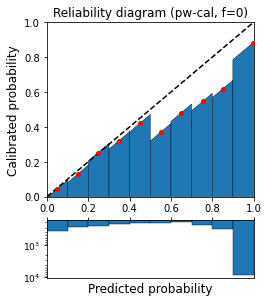

In [28]:
generate_rel_diagrams(np.clip(probs2_cal_test, 0, 1), ys2_test, equal_size = False, title_str = "Reliability diagram (pw-cal, f=%i)")
plt.savefig("rel_diag_gmm_cal_f0.pdf", bbox_inches='tight')

#### Object-wise calibration

In [29]:
probs_test_objcal = cal_obj(probs_val, probs_test, ys_val, ys_test)

ECE test uncal: 0.1838914146721039
ECE test cal: 0.018211231742214697


In [30]:
probs_val.shape, probs_test.shape

((3477,), (13810,))


ECE_abs: 0.018211231742214697
Bins: [279, 642, 732, 757, 359, 34, 1, 0, 11006, 0]
Conf: [0.06151809608989296, 0.15103715821246136, 0.24974874236926908, 0.34596912557395393, 0.4380194281773135, 0.5285337884309407, 0.603868086270717, nan, 0.8330175479727889, nan]
Acc: [0.04659498207885305, 0.1542056074766355, 0.296448087431694, 0.36988110964332893, 0.4233983286908078, 0.4117647058823529, 0.0, nan, 0.8163728875159004, nan]


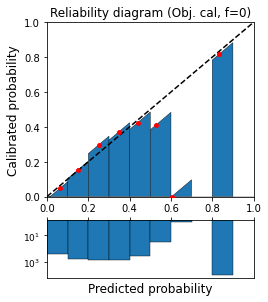

In [31]:
generate_rel_diagrams(np.clip(probs_test_objcal, 0, 1), ys_test, equal_size = False, title_str = "Reliability diagram (Obj. cal, f=%i)")
plt.savefig("rel_diag_obj_cal_f0.pdf", bbox_inches='tight')

### 2.2 Location Uncertainty

In [32]:
def rel_diag_quantiles(data, l = 100, nr_future = 0, extra_str = "width", label = ""):
    qs = np.linspace(1/l, 1, l)
    plt.plot(qs, np.quantile(data, qs), label = label)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("Predicted Cumulative Distribution")
    plt.ylabel("Empirical Cumulative Distribution")
    plt.title("Regression Calibration (%s, f=%i)" % (extra_str, nr_future))

In [33]:
def rel_diag_quantiles_cal(data, l = 100, nr_future = 0, extra_str = "width", label = ""):
    qs = np.linspace(1/l, 1, l)
    plt.plot(qs, data, label = label)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("Predicted Cumulative Distribution")
    plt.ylabel("Empirical Cumulative Distribution")
    plt.title("Regression Calibration (%s, f=%i)" % (extra_str, nr_future))

In [34]:
def q_cal_map(inp_val, inp_test, l = 100):
    qs = np.linspace(1/l, 1, l)
    w = np.quantile(inp_val[:, 0], qs)
    h = np.quantile(inp_val[:, 1], qs)
    w_cal = np.interp(np.quantile(inp_test[:,0], qs), w, qs)
    h_cal = np.interp(np.quantile(inp_test[:,1], qs), h, qs)

    return np.stack([w_cal, h_cal]).T

In [35]:
quantiles_objcal_test = q_cal_map(quantiles_val, quantiles_test)

In [36]:
quantiles_val.shape, quantiles_test.shape

((2497, 2), (9760, 2))

In [37]:
quantiles_objcal_test.shape

(100, 2)

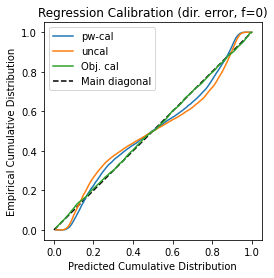

In [38]:
rel_diag_quantiles(np.array(quantiles_cal_test)[:, 0], label = "pw-cal")  # X for width; blue
rel_diag_quantiles(np.array(quantiles_test)[:, 0], label = "uncal")  # X for width; orange
rel_diag_quantiles_cal(quantiles_objcal_test[:, 0], label = "Obj. cal", extra_str = "dir. error")  # X for width; orange
plt.plot([0,1], [0,1], "--", c="black", label="Main diagonal", zorder=1, alpha=1)

plt.legend()
plt.savefig("fig_cal_location_width.pdf", bbox_inches='tight')

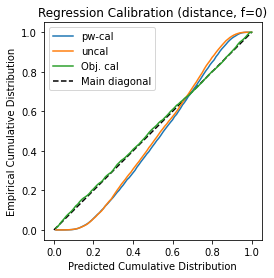

In [39]:
rel_diag_quantiles(np.array(quantiles_cal_test)[:, 1], extra_str="distance", label = "pw-cal")  # Y for distance
rel_diag_quantiles(np.array(quantiles_test)[:, 1], extra_str="distance", label = "uncal")  # Y for width
rel_diag_quantiles_cal(quantiles_objcal_test[:, 1], label = "Obj. cal", extra_str = "distance")  # X for width; orange
plt.plot([0,1], [0,1], "--", c="black", label="Main diagonal", zorder=1, alpha=1)

plt.legend()
plt.savefig("fig_cal_location_distance.pdf", bbox_inches='tight')

### 2.3 Trajectory uncertainty

#### 2.3.1 Trajectory presence uncertainty


ECE_abs: 0.16992507218591418
Bins: [238, 249, 228, 206, 188, 243, 204, 216, 213, 11079]
Conf: [0.0497582, 0.15124509, 0.24930194, 0.35106656, 0.45128533, 0.5518933, 0.64992046, 0.7510965, 0.8460411, 0.9991208]
Acc: [0.03361344537815126, 0.1285140562248996, 0.15789473684210525, 0.2912621359223301, 0.324468085106383, 0.35802469135802467, 0.4215686274509804, 0.4583333333333333, 0.4694835680751174, 0.826157595450853]


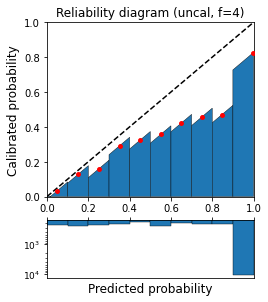

In [40]:
generate_rel_diagrams(np.clip(probs_test_f4, 0, 1), ys_test_f4, nr_future = 4, 
                      title_str = "Reliability diagram (uncal, f=%i)")
plt.savefig("rel_diag_uncal_f4.pdf", bbox_inches='tight')


ECE_abs: 0.1434844640973565
Bins: [236, 265, 276, 271, 319, 347, 384, 415, 434, 10117]
Conf: [0.050712861845028594, 0.15158671762744766, 0.24906914763497512, 0.3512997591194768, 0.44937617097974825, 0.548645177875033, 0.6510990599737009, 0.7482674807570511, 0.8527668032217051, 0.9975701059570837]
Acc: [0.029661016949152543, 0.12452830188679245, 0.20652173913043478, 0.3948339483394834, 0.3322884012539185, 0.4812680115273775, 0.5078125, 0.5590361445783133, 0.6175115207373272, 0.8451121874073342]


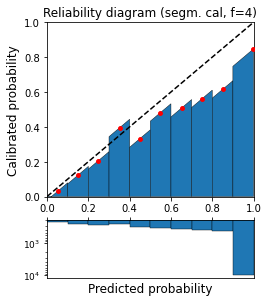

In [41]:
generate_rel_diagrams(np.clip(probs_cal_test_f4, 0, 1), ys_test_f4, nr_future = 4, 
                      title_str = "Reliability diagram (segm. cal, f=%i)")
plt.savefig("rel_diag_segm_cal_f4.pdf", bbox_inches='tight')


ECE_abs: 0.09837702683809893
Bins: [289, 262, 250, 217, 232, 207, 217, 230, 249, 8852]
Conf: [0.04516984521611562, 0.14905108652213178, 0.24755709252029842, 0.34885765659828183, 0.4487858266882392, 0.5493593583098092, 0.6528555255465979, 0.7497442227527593, 0.8514250115053439, 0.9984296372838519]
Acc: [0.04844290657439446, 0.12213740458015267, 0.184, 0.2903225806451613, 0.3448275862068966, 0.41545893719806765, 0.511520737327189, 0.5391304347826087, 0.642570281124498, 0.9009263443289652]


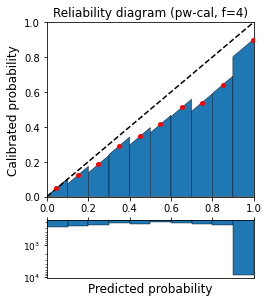

In [42]:
generate_rel_diagrams(np.clip(probs2_cal_test_f4, 0, 1), ys2_test_f4, nr_future = 4, 
                      title_str = "Reliability diagram (pw-cal, f=%i)")
plt.savefig("rel_diag_gmm_cal_f4.pdf", bbox_inches='tight')

In [43]:
probs_test_objcal_f4 = cal_obj(probs_val_f4, probs_test_f4, ys_val_f4, ys_test_f4)

ECE test uncal: 0.16992507218591418
ECE test cal: 0.007514043560005493


In [44]:
probs_val_f4.shape, probs_test_f4.shape

((3441,), (13064,))


ECE_abs: 0.007514043560005493
Bins: [338, 387, 375, 488, 428, 166, 7, 1, 10874, 0]
Conf: [0.05085841391463719, 0.1498612896687627, 0.250977415649584, 0.34929391279000277, 0.44460877467206683, 0.5314006214621673, 0.6377318635150179, 0.7010737136790718, 0.8277389058728899, nan]
Acc: [0.05325443786982249, 0.1524547803617571, 0.31733333333333336, 0.38114754098360654, 0.4742990654205608, 0.5301204819277109, 0.7142857142857143, 1.0, 0.8316167003862424, nan]


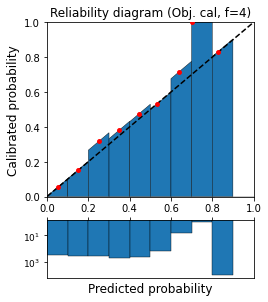

In [45]:
generate_rel_diagrams(np.clip(probs_test_objcal_f4, 0, 1), ys_test_f4, equal_size = False, 
                      nr_future = 4, title_str = "Reliability diagram (Obj. cal, f=%i)")
plt.savefig("rel_diag_obj_cal_f4.pdf", bbox_inches='tight')

#### 2.3.2 Trajectory location uncertainty

In [46]:
quantiles_objcal_test_f4 = q_cal_map(quantiles_val_f4, quantiles_test_f4)

In [47]:
quantiles_val_f4.shape, quantiles_test_f4.shape

((2508, 2), (9722, 2))

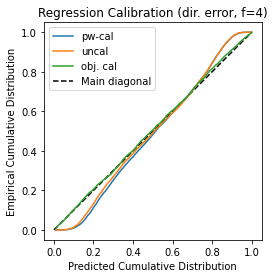

In [48]:
rel_diag_quantiles(np.array(quantiles_cal_test_f4)[:, 0], label = "pw-cal", nr_future = 4)  # X for width; blue
rel_diag_quantiles(np.array(quantiles_test_f4)[:, 0], label = "uncal", nr_future = 4)  # X for width; orange
rel_diag_quantiles_cal(quantiles_objcal_test_f4[:, 0], label = "obj. cal", nr_future = 4, extra_str = "dir. error")  # X for width; orange
plt.plot([0,1], [0,1], "--", c="black", label="Main diagonal", zorder=1, alpha=1)

plt.legend()
plt.savefig("fig_cal_location_width_f4.pdf", bbox_inches='tight')

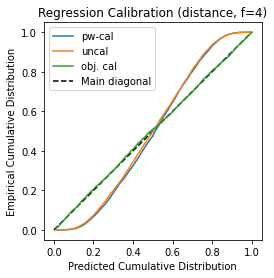

In [49]:
rel_diag_quantiles(np.array(quantiles_cal_test_f4)[:, 1], label = "pw-cal")  # Y for distance
rel_diag_quantiles(np.array(quantiles_test_f4)[:, 1], label = "uncal")  # Y for width
rel_diag_quantiles_cal(quantiles_objcal_test_f4[:, 1], label = "obj. cal", nr_future = 4, extra_str="distance")  # X for width; orange
plt.plot([0,1], [0,1], "--", c="black", label="Main diagonal", zorder=1, alpha=1)

plt.legend()
plt.savefig("fig_cal_location_distance_f4.pdf", bbox_inches='tight')

### 2.4 Undetected uncertainty


ECE_abs: 0.011250326973580397
Bins: [410, 410, 410, 410, 410, 410, 409, 409, 409, 409]
Conf: [0.0, 0.00011038690058731318, 0.0005511449143493529, 0.0011624470240454293, 0.0022124820467689637, 0.003992953264300167, 0.00683697478426285, 0.012630519011925202, 0.024146105344384917, 0.11479539714858181]
Acc: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0024390243902439024, 0.0, 0.009779951100244499, 0.009779951100244499, 0.03178484107579462]


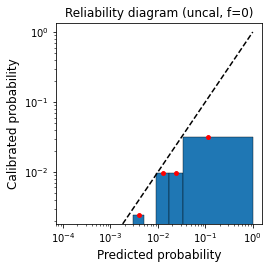

In [50]:
generate_rel_diagrams(np.clip(probs_test_un, 0, 1), ys_test_un, equal_size = True, title_str = "Reliability diagram (uncal, f=%i)")
plt.savefig("rel_diag_uncal_f0_un_pw_10m.pdf", bbox_inches='tight')

In [51]:
probs_test_un.shape

(4096,)

In [52]:
probs_val_un.shape

(1023,)


ECE_abs: 0.041353253631573494
Bins: [410, 410, 410, 410, 410, 410, 409, 409, 409, 409]
Conf: [0.0, 0.0046949086529754665, 0.021604880023471374, 0.029548484158507696, 0.03330066786955552, 0.03806982278573542, 0.04418155935453728, 0.054481256254892106, 0.07162411072684886, 0.17011217841659312]
Acc: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0024449877750611247, 0.009779951100244499, 0.014669926650366748, 0.02689486552567237]


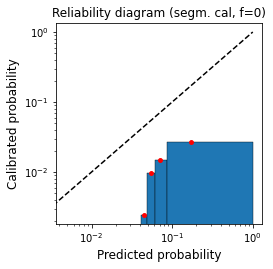

In [53]:
generate_rel_diagrams(np.clip(probs_cal_test_un, 0, 1), ys_test_un, equal_size = True, title_str = "Reliability diagram (segm. cal, f=%i)")
plt.savefig("rel_diag_segm_cal_f0_un_pw_10m.pdf", bbox_inches='tight')


ECE_abs: 0.06860449621200493
Bins: [410, 410, 410, 410, 410, 410, 409, 409, 409, 409]
Conf: [0.0, 0.0003585578764525452, 0.012207442846432437, 0.027424090072786275, 0.031433901972798974, 0.03610141123365505, 0.042419332109747236, 0.0526359318760904, 0.06997792014672509, 0.21832270654467142]
Acc: [0.0, 0.0, 0.11707317073170732, 0.08780487804878048, 0.0951219512195122, 0.09024390243902439, 0.13691931540342298, 0.1784841075794621, 0.18092909535452323, 0.1466992665036675]


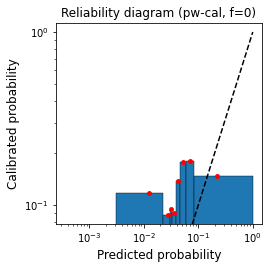

In [54]:
generate_rel_diagrams(np.clip(probs2_cal_test_un, 0, 1), ys2_test_un, equal_size = True, title_str = "Reliability diagram (pw-cal, f=%i)")
plt.savefig("rel_diag_gmm_cal_f0_un_pw_10m.pdf", bbox_inches='tight')

In [55]:
probs_test_objcal_un = cal_obj(probs_val_un, probs_test_un, ys_val_un, ys_test_un)

ECE test uncal: 0.011250326973580397
ECE test cal: 0.0027996218450295385



ECE_abs: 0.0029047647670050855
Bins: [410, 410, 410, 410, 410, 410, 409, 409, 409, 409]
Conf: [1.9198550564930724e-11, 0.0003834106180964249, 0.0012594113407196161, 0.0020225897242325576, 0.0030356358300097103, 0.00440414259438981, 0.006176625612975369, 0.009071273482658323, 0.013605499637920841, 0.0414768952579912]
Acc: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0024390243902439024, 0.0, 0.009779951100244499, 0.009779951100244499, 0.03178484107579462]


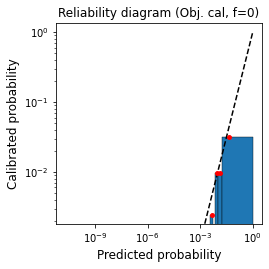

In [56]:
generate_rel_diagrams(np.clip(probs_test_objcal_un, 0, 1), ys_test_un, equal_size = True, title_str = "Reliability diagram (Obj. cal, f=%i)")
plt.savefig("rel_diag_obj_cal_f0_un_pw_10m.pdf", bbox_inches='tight')